# **Targeted EDA for Funding Strategy Analysis M2 Phase**

By: Allison Kramer


**Domain Question 4:** What underlying patterns emerge in how federal agencies structure and distribute grant funding?


**Problem Statement:**

This analysis explores underlying patterns in how federal agencies structure and distribute grant funding. Identifying these patterns can reveal whether agencies prioritize broad access, high-impact funding, or specialized initiatives. It can allow for insight into if they are favoring certain profiles over others - allowing for reflecton on if they should be investing more funding elsewhere. Its key to distinguish this question is comparing agencies and not individual opportunities.

While initial EDA provided a broad understanding of the dataset, additional targeted exploration was conducted to identify features most relevant for detecting agency-level funding strategy profiles.

In [2]:
import pandas as pd

grants = pd.read_csv("https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-10-03/grants.csv")

details = pd.read_csv("https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-10-03/grant_opportunity_details.csv")

/tmp/ipython-input-608325893.py:3: DtypeWarning: Columns (6,8,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  grants = pd.read_csv("https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-10-03/grants.csv")


In [3]:
print(f"Grants: ", grants.shape)
print(f"Details: ", details.shape)

Grants:  (74669, 17)
Details:  (2000, 68)


In [4]:
grants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74669 entries, 0 to 74668
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   opportunity_id                  74669 non-null  int64  
 1   opportunity_number              74669 non-null  object 
 2   opportunity_title               74669 non-null  object 
 3   agency_code                     74626 non-null  object 
 4   agency_name                     74625 non-null  object 
 5   estimated_funding               53043 non-null  float64
 6   expected_number_of_awards       53371 non-null  object 
 7   grantor_contact                 74638 non-null  object 
 8   agency_contact_phone            668 non-null    object 
 9   agency_contact_email            73791 non-null  object 
 10  estimated_post_date             517 non-null    object 
 11  estimated_application_due_date  574 non-null    object 
 12  posted_date                     

In [5]:
details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 68 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   opportunity_id                                                       2000 non-null   int64  
 1   funding_opportunity_number                                           2000 non-null   object 
 2   funding_opportunity_title                                            2000 non-null   object 
 3   opportunity_category                                                 2000 non-null   object 
 4   opportunity_category_explanation                                     53 non-null     object 
 5   expected_number_of_awards                                            619 non-null    float64
 6   cost_sharing_or_matching_requirement                                 2000 non-null   bool   
 7   versio

## **Additional EDA: Pre-Clustering Diagnostics**

This exploratory analysis focuses on identifying whether federal agencies exhibit distinct funding strategy profiles based on funding scale, award volume, and reporting behavior.

### **1. Dataset Structure and Coverage**

In [6]:
grants['opportunity_id'].nunique()
details['opportunity_id'].nunique()

2000

In [7]:
# See if its possible to Merge - Ideally .80 and Above

set(grants['opportunity_number']).intersection(
    set(details['funding_opportunity_number']))

matches = grants['opportunity_number'].isin(
    details['funding_opportunity_number']).mean()

matches

#result is 0.02 --> bad match

np.float64(0.026798269696929115)

Details covers only ~2 - 3% of rows → don't merge for core analysis (bad match)

In [8]:
grants['estimated_funding'].isna().mean()

np.float64(0.2896248777939975)

**The opportunity details dataset covers only a small fraction of the primary grants data (~3%). Merging these datasets would introduce substantial sampling bias, so further analysis will focus on the primary grants dataset while reserving the details table for contextual interpretation.**

### **2. Missing Data Assessment**
Understanding missing data patterns is good when comparing agency strategies, as uneven reporting may distort funding comparisons.

In [9]:
# Examining whether funding data is missing systematically across agencies

# Missing Funding Rate by Agency (Top 15 Agencies by Volume)

top_agencies = grants['agency_name'].value_counts().head(15).index

missing_by_agency = (grants[grants['agency_name'].isin(top_agencies)]
                     .groupby('agency_name')['estimated_funding']
                     .apply(lambda s: s.isna().mean())
                     .sort_values(ascending=False))

missing_by_agency


,estimated_funding
agency_name,
NASA Headquarters,0.975355
National Institutes of Health,0.724353
Geological Survey,0.266551
Centers for Disease Control and Prevention,0.199189
Department of Commerce,0.141230
Department of Education,0.134831
National Science Foundation,0.057273
National Park Service,0.054237
Fish and Wildlife Service,0.038574


NASA Headquarters and National Institutes of Health has over a lot missing - it will effect comparability. NASA → ~97% missing & NIH → ~72% missing

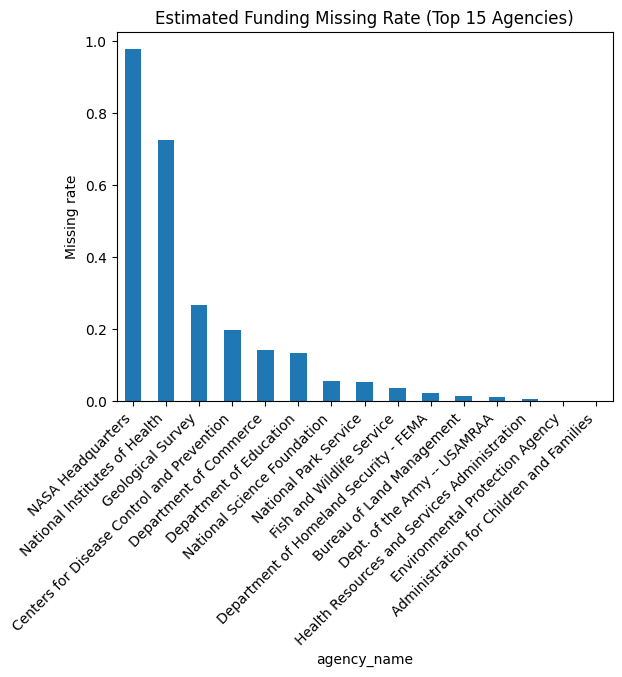

In [10]:
import matplotlib.pyplot as plt

missing_by_agency.plot(kind='bar')
plt.title("Estimated Funding Missing Rate (Top 15 Agencies)")
plt.ylabel("Missing rate")
plt.xticks(rotation=45, ha='right')
plt.show()

**Missing funding varies substantially across agencies, with some major agencies (e.g., NASA Headquarters and NIH) reporting estimated funding for only a small fraction of opportunities. On the other hand, others demonstrate near complete reporting. This inconsistency limits direct comparability and suggests that agency-level summaries must be interpreted cautiously.**

### **3. Distribution of Funding**
Examining the distribution of estimated funding helps determine whether transformations are necessary before comparing agencies. The idea is to hopefully understand the distribution of estimated funding values.

In [11]:
grants['estimated_funding'].describe()

,estimated_funding
count,5.304300e+04
mean,2.287264e+07
std,8.463689e+08
min,0.000000e+00
25%,1.000000e+05
50%,8.750000e+05
75%,5.000000e+06
max,1.780000e+11


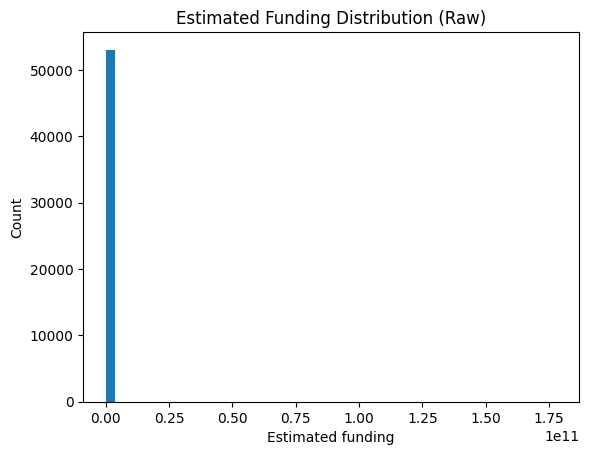

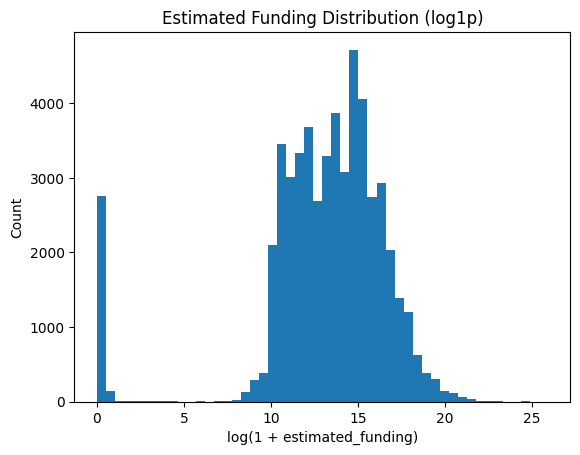

In [12]:
import matplotlib.pyplot as plt
import numpy as np

x = grants['estimated_funding'].dropna()

plt.hist(x, bins=50)
plt.title("Estimated Funding Distribution (Raw)")
plt.xlabel("Estimated funding")
plt.ylabel("Count")
plt.show()

plt.hist(np.log1p(x), bins=50)
plt.title("Estimated Funding Distribution (log1p)")
plt.xlabel("log(1 + estimated_funding)")
plt.ylabel("Count")
plt.show()

**Estimated funding is highly right-skewed, with a small number of extremely large opportunities driving the upper tail. After applying a log transformation, the distribution becomes more symmetric, indicating that funding differences operate multiplicatively rather than linearly.**

### **4. Expected Awards Exploration**


In [13]:
grants['expected_number_of_awards'].value_counts().head(20)

,count
expected_number_of_awards,
1.0,24713
1,2812
2.0,2482
10.0,2105
5.0,1940
3.0,1831
4.0,1554
0.0,1428
6.0,1128


In [14]:
grants['expected_awards_num'] = pd.to_numeric(grants['expected_number_of_awards'], errors='coerce')

grants['expected_awards_num'].describe()

,expected_awards_num
count,5.335300e+04
mean,7.280219e+03
std,1.163889e+06
min,0.000000e+00
25%,1.000000e+00
50%,1.000000e+00
75%,8.000000e+00
max,2.640000e+08


**Expected award counts display extreme variability, with most opportunities offering very few awards while a small number distribute thousands. This suggests that the variable may require transformation or capping to prevent outliers from disproportionately influencing similarity measures.**

### **5. Agency-Level Aggregation**
Constructing Agency Level Profiles

Because this research question focuses on agency strategy rather than individual opportunities, grant level data was aggregated to construct agency level summaries.


In [15]:
grants['expected_awards_num'].isna().mean()

np.float64(0.285473221818961)

In [16]:
grants['expected_awards_num'] = pd.to_numeric(grants['expected_number_of_awards'], errors='coerce')

In [17]:
agency_profile = (grants.groupby('agency_name')
                  .agg(
                      n_opps=('opportunity_id','count'),
                      avg_funding=('estimated_funding','mean'),
                      med_funding=('estimated_funding', 'median'),
                      avg_awards=('expected_awards_num','mean'),
                      med_awards=('expected_awards_num', 'median'),
                      funding_missing_rate=('estimated_funding', lambda s: s.isna().mean())
                  )
                  .reset_index())

agency_profile.sort_values('n_opps', ascending=False).head(10)

,agency_name,n_opps,avg_funding,med_funding,avg_awards,med_awards,funding_missing_rate
336,National Institutes of Health,11239,6.244770e+06,3000000.0,3924.891850,4.0,0.724353
338,National Park Service,8426,5.961203e+05,61000.0,186.935621,1.0,0.054237
209,Fish and Wildlife Service,4122,1.646400e+06,99000.0,166.960866,1.0,0.038574
78,Bureau of Land Management,2868,8.687874e+05,200000.0,776.749605,1.0,0.015690
221,Geological Survey,2311,4.645448e+05,75749.0,2.245690,1.0,0.266551
123,Centers for Disease Control and Prevention,1727,2.230190e+07,2122500.0,5682.843858,1.0,0.199189
233,Health Resources and Services Administration,1609,3.813759e+07,3070300.0,30.627488,8.0,0.005594
167,Department of Education,1513,9.723368e+07,3750000.0,8630.163985,8.0,0.134831
181,Dept. of the Army -- USAMRAA,1507,1.044582e+07,4800000.0,8.691739,4.0,0.013271
198,Environmental Protection Agency,1371,2.949487e+07,2000000.0,20.399113,8.0,0.001459


**Substantial variation emerges across agencies in both funding scale and award volume. Some agencies appear to distribute fewer, larger awards, while others fund a greater number of smaller opportunities. These early patterns provide preliminary evidence that agencies may operate under distinct funding strategies.**

**Because the research question is inherently agency-level, clustering will be performed on aggregated features rather than individual opportunities to ensure that inferred strategy profiles reflect institutional behavior rather than grant-level noise.**

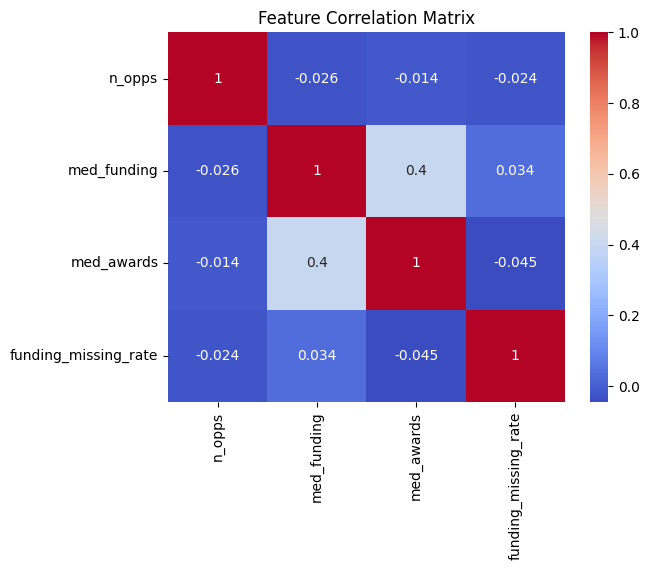

In [18]:
#Checking to make sure no features are super correlated

import seaborn as sns

#features = agency_profile[['n_opps','avg_funding','med_funding', 'med_awards', 'avg_awards','funding_missing_rate']]
features = agency_profile[['n_opps', 'med_funding', 'med_awards', 'funding_missing_rate']].copy()

sns.heatmap(features.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

**Features are NOT strongly correlated... there are minimal relationships between the my chosen selected features, indicating that each captures a different dimension of agency funding behavior. This lack of redundancy supports the possibility of joint use in clustering, as no single variable is likely to dominate the distance calculations. It also suggests that agencies may pursue fundamentally different funding strategies - proividing some strong insights to anwser domain question.**

### **6. Opportunities by Agency**

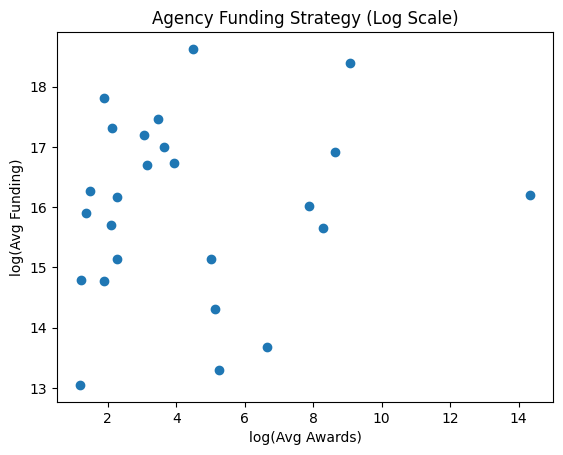

In [19]:
#this needs to be run after 6. --> fix it
topN = agency_profile.sort_values('n_opps', ascending=False).head(25)

plt.scatter(
    np.log1p(topN['avg_awards']),
    np.log1p(topN['avg_funding'])
)

plt.xlabel("log(Avg Awards)")
plt.ylabel("log(Avg Funding)")
plt.title("Agency Funding Strategy (Log Scale)")
plt.show()



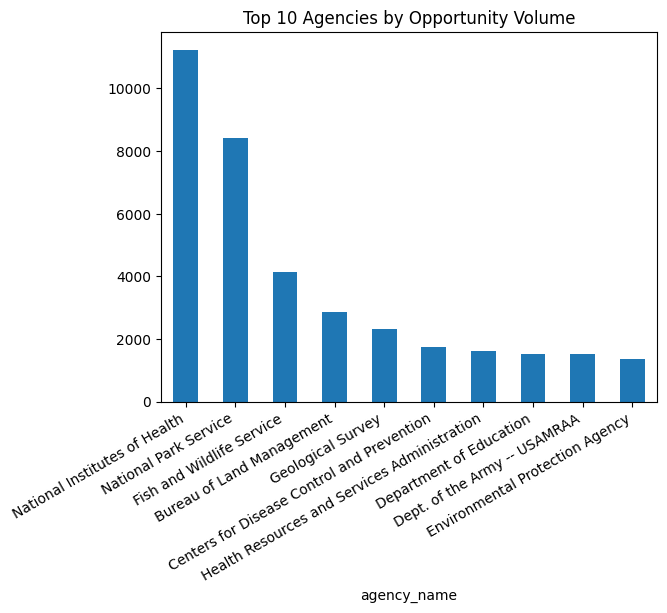

In [20]:
agency_counts = grants['agency_name'].value_counts().head(10)

agency_counts.plot(kind='bar')
plt.title("Top 10 Agencies by Opportunity Volume")
plt.xticks(rotation=30, ha='right')
plt.show()



**Opportunity volume is heavily concentrated among a small number of agencies, suggesting that representation imbalance must be considered when comparing strategies.**

### **7. Strategy for Scattering**

**Median Funding vs Median Awards**

(659, 4)


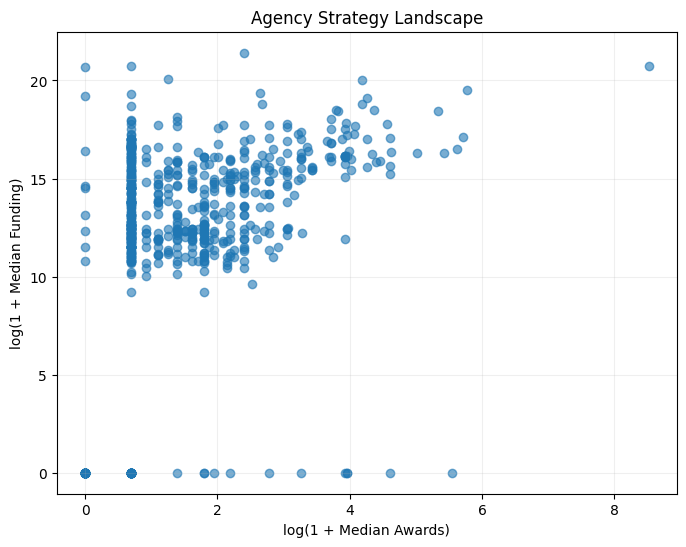

In [21]:
#I want to see if any natural clusters started forming
import numpy as np
import matplotlib.pyplot as plt

# Make sure features exists
print(features.shape)

# Create log columns (fixes skew + avoids plotting errors)
# features['log_med_awards'] = np.log1p(features['med_awards'])
# features['log_med_funding'] = np.log1p(features['med_funding'])

features['log_n_opps'] = np.log1p(features['n_opps'])
features['log_med_funding'] = np.log1p(features['med_funding'].fillna(0))
features['log_med_awards'] = np.log1p(features['med_awards'].fillna(0))


# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(
    features['log_med_awards'],
    features['log_med_funding'],
    alpha=0.6
)
plt.xlabel("log(1 + Median Awards)")
plt.ylabel("log(1 + Median Funding)")
plt.title("Agency Strategy Landscape")
plt.grid(alpha=0.2)
plt.show()


**The median-based comparison reveals clear variation in agency funding strategies. While many agencies cluster around similar median award counts, their funding levels differ substantially, suggesting distinct approaches to grant distribution. Additionally, one extreme low - funding observation may reflect either reporting irregularities or fundamentally different grant structures, warranting further review prior to clustering.**

## **Unsupervised Machine Learning M2 Phase**

**What I Have Already Done: (Additional EDA)**
1. The exploratory analysis identified meaningful variation across agencies in funding size, award volume, and opportunity scale.

2. Features were aggregated to the agency level to reflect strategic behavior rather than individual grant characteristics.

3. Skewed financial variables were log-transformed where appropriate, and correlation analysis suggests the selected features capture relatively independent dimensions of funding strategy.

4. These findings support the use of unsupervised learning to identify potential funding strategy profiles across federal agencies.

### **1. Preparing Data for Clustering**



In [22]:
agency_profile.columns

Index(['agency_name', 'n_opps', 'avg_funding', 'med_funding', 'avg_awards',
       'med_awards', 'funding_missing_rate'],
      dtype='object')

In [23]:
import numpy as np

# Choosing my Features
features = agency_profile[['n_opps', 'med_funding', 'med_awards', 'funding_missing_rate']].copy()

# Create Log Features --> directly into dataframe
features.loc[:, 'log_n_opps'] = np.log1p(features['n_opps'])
features.loc[:, 'log_med_funding'] = np.log1p(features['med_funding'])
features.loc[:, 'log_med_awards'] = np.log1p(features['med_awards'])

# Final Feature Set Before Clustering
features = features[['log_n_opps', 'log_med_funding', 'log_med_awards', 'funding_missing_rate']].copy()

**To capture agency funding strategy, clustering was performed on four dimensions: opportunity volume (n_opps), typical funding level (med_funding), award size (med_awards), and reporting consistency (funding_missing_rate). Together, these variables approximate how aggressively and transparently agencies distribute federal funding.**

In [24]:
# KMeans cannot handle NaNs, rows with missing data will be removed for clustering
features.isna().sum().sort_values(ascending=False)
features_clean = features.dropna()

In [25]:
#Scale
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_clean)

### **2. Determining the Optimal Number of Clusters**

**Find K - Elbow and Silhoutte**

**1. Elbow**

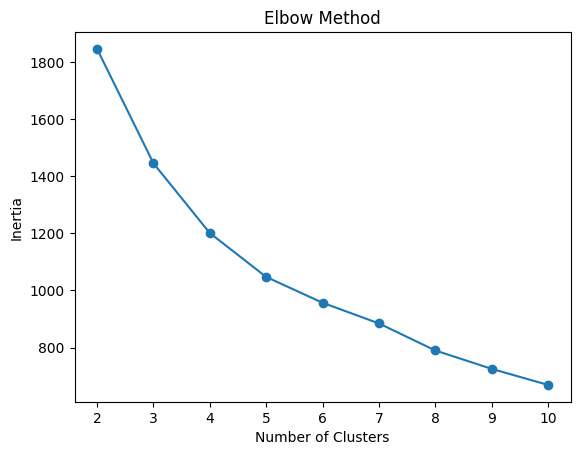

In [26]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(2, 11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

**The elbow begins forming around k=4, suggesting that 4 clusters likely capture the primary structure before marginal improvements diminish.**

**2. Silhoutte**

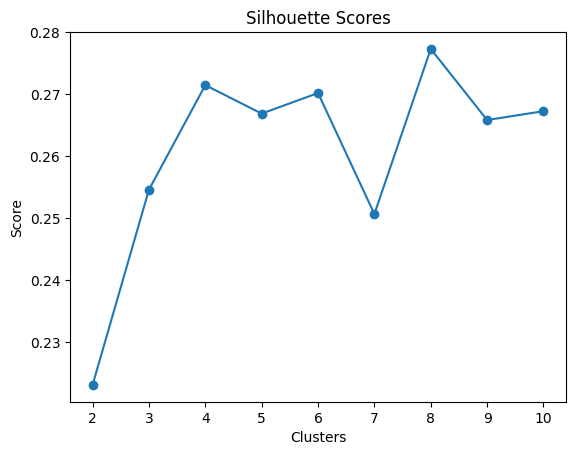

In [27]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))

plt.plot(range(2,11), scores, marker='o')
plt.title("Silhouette Scores")
plt.xlabel("Clusters")
plt.ylabel("Score")
plt.show()

**Although silhouette scores were slightly higher at larger k values, additional clusters created fragmented groups that were difficult to interpret strategically. A four cluster solution provided the best balance between statistical fit and practical interpretability.**

### **3. Fitting Model**

In [28]:
#Running K-Means & Picking 4 as my k

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

#Attatch Cluster Labels to Agencies
agency_profile_clean = agency_profile.loc[features_clean.index].copy()
agency_profile_clean['cluster'] = clusters


In [29]:
#Profile the Clusters

cluster_summary = agency_profile_clean.groupby('cluster')[['n_opps',
                                                           'med_funding',
                                                           'med_awards',
                                                           'funding_missing_rate'
                                                           ]].median()

cluster_summary

,n_opps,med_funding,med_awards,funding_missing_rate
cluster,,,,
0,7.0,225000.0,3.0,0.083333
1,24.0,3000000.0,1.0,0.583333
2,11.0,11250000.0,40.0,0.037037
3,145.5,1650000.0,2.0,0.116531


In [30]:
#Seeing if What Was Removed Would Impact Clustering

print("Original Amount:", len(features))
print("After dropna:", len(features_clean))

amount_removed = len(features) - len(features_clean)
print(f"Amount Removed: ", amount_removed)

pct_removed = 1 - (len(features_clean) / len(features))
print(f"Percent Removed: %", round(pct_removed, 4)*100)

Original Amount: 659
After dropna: 592
Amount Removed:  67
Percent Removed: % 10.17


**Approximately 10% of agencies were removed due to missing values. Because the majority of observations were retained, the risk of systematic bias in the clustering results is likely low.**

### **4. Visualizing the Clusters / Interpreting the Model**

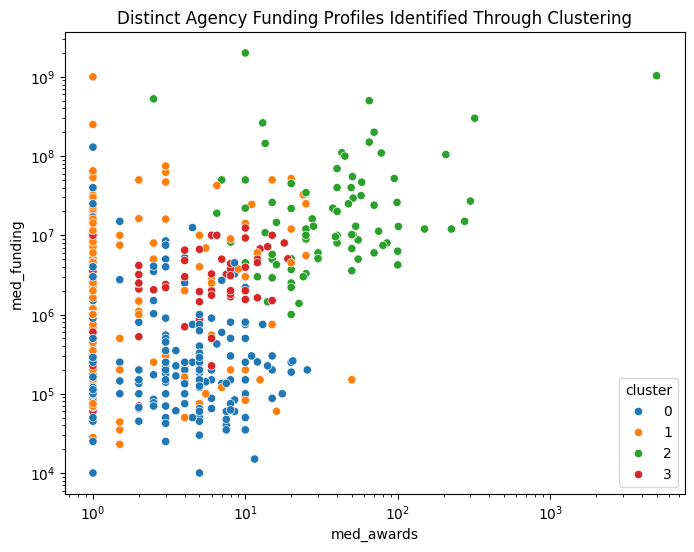

In [44]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=agency_profile_clean,
    x='med_awards',
    y='med_funding',
    hue='cluster',
    palette='tab10'
)

plt.xscale('log')
plt.yscale('log')

plt.title("Distinct Agency Funding Profiles Identified Through Clustering")
plt.show()


**Breif Interpretation:** **The Green Cluster:** mostly high funding along with higher awards, likely major funding agencies. **The Blue Cluster:** lower funding and lower awards, probably smaller agencies. **The Red Cluster:** mid range funding with not a huge counts, likely for possible specialized grants. **The Orange Cluster:** its pretty spread across funding levels, but it looks like lower awards so maybe inconsistent funding strategies for this cluster is present.

In [41]:
# Assign descriptive labels for interpretability
cluster_labels = {
    0: "Lower Funding / Smaller Awards",
    1: "Moderate Funding, Few Awards",
    2: "High Funding Agencies",
    3: "High Opportunity Agencies"}

agency_profile_clean['cluster_label'] = agency_profile_clean['cluster'].map(cluster_labels)

In [42]:
# Checking Table for Cluster Amount

cluster_profile = agency_profile_clean.groupby('cluster').agg({'n_opps':'median',
                                                               'med_funding':'median',
                                                               'med_awards':'median',
                                                               'funding_missing_rate':'median'})

cluster_profile['cluster_size'] = agency_profile_clean['cluster'].value_counts()

cluster_profile.sort_index()


,n_opps,med_funding,med_awards,funding_missing_rate,cluster_size
cluster,,,,,
0,7.0,225000.0,3.0,0.083333,235
1,24.0,3000000.0,1.0,0.583333,166
2,11.0,11250000.0,40.0,0.037037,91
3,145.5,1650000.0,2.0,0.116531,100


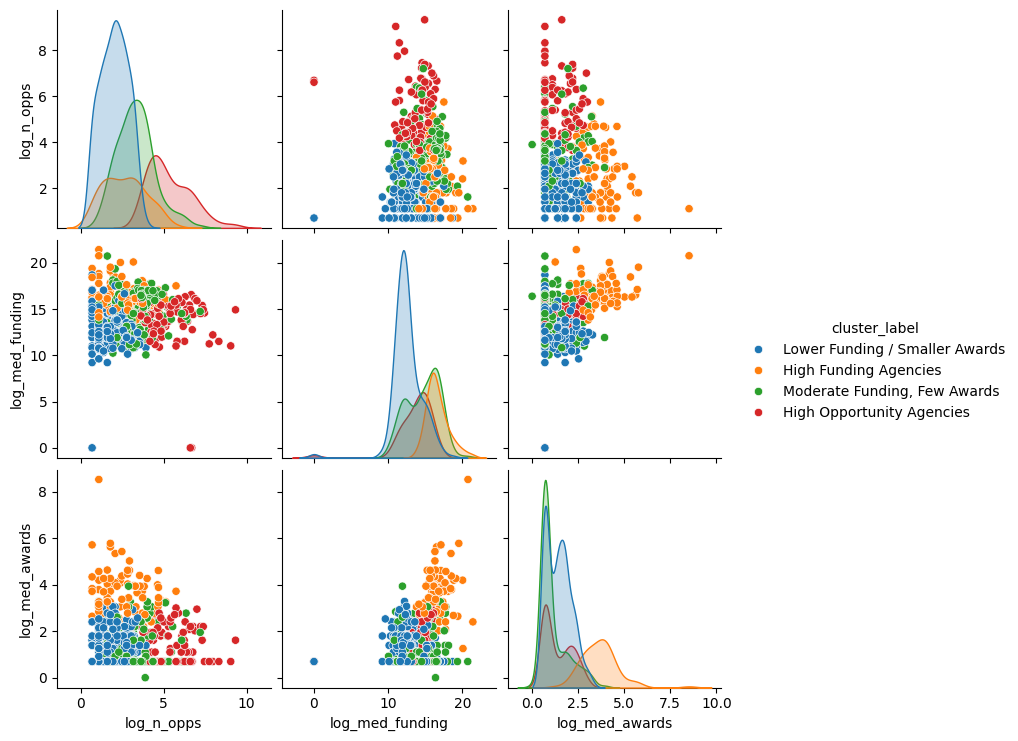

In [43]:
plot_df = features_clean.copy()
#plot_df['cluster'] = agency_profile_clean['cluster']
plot_df['cluster_label'] = agency_profile_clean['cluster_label']

sns.pairplot(
    plot_df,
    vars=['log_n_opps','log_med_funding','log_med_awards'],
    hue='cluster_label',
    palette='tab10'
)

plt.show()



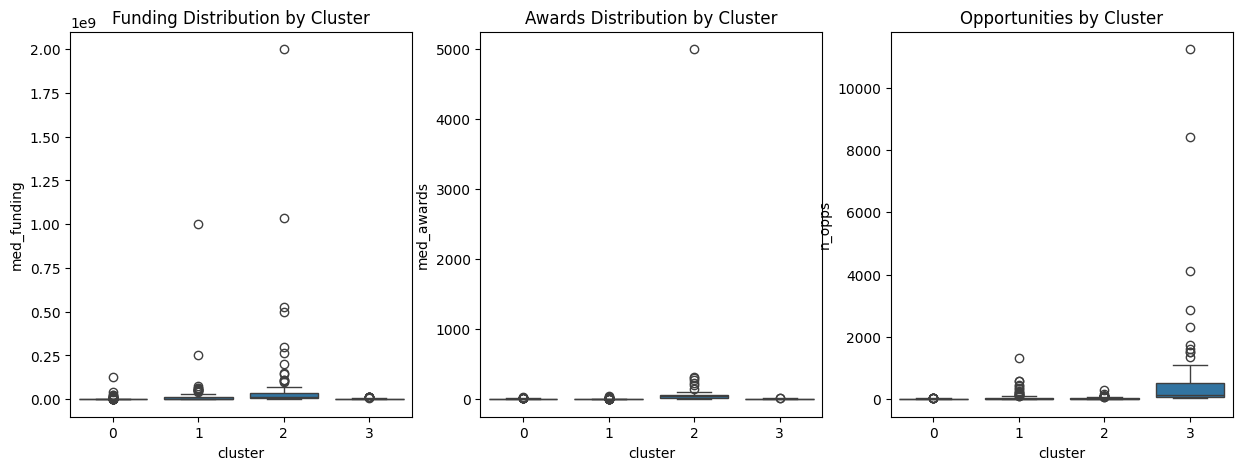

In [35]:
fig, axes = plt.subplots(1,3, figsize=(15,5))

sns.boxplot(data=agency_profile_clean, x='cluster', y='med_funding', ax=axes[0])
axes[0].set_title("Funding Distribution by Cluster")

sns.boxplot(data=agency_profile_clean, x='cluster', y='med_awards', ax=axes[1])
axes[1].set_title("Awards Distribution by Cluster")

sns.boxplot(data=agency_profile_clean, x='cluster', y='n_opps', ax=axes[2])
axes[2].set_title("Opportunities by Cluster")

plt.show()

**The clustering analysis reveals distinct agency funding strategies rather than perfectly separated groups. One cluster is characterized by substantially higher funding levels and award counts, indicating large scale funding institutions. Another cluster demonstrates high opportunity volume with more moderate funding levels, suggesting a strategy focused on distributing resources across many programs. Meanwhile, smaller clusters represent agencies with lower funding footprints, likely reflecting specialized or niche funding priorities. The presence of some overlap is expected in real-world financial data and reinforces that agency behaviors exist along a spectrum rather than within rigid boundaries.**